# Plotly: Interactive Visualization

In [1]:
import numpy as np
import pandas as pd
import janitor
import plotly
import plotly.express as px
import plotly.graph_objects as go

## 1. Introduction
[Plotly] is an Python library interactive, open-source plotting library that supports over 40 unique chart types covering a wide range of statistical, financial, geographic, scientific, and 3-dimensional use-cases.

Plotly has two important submodules,
<code style="font-size:13px">plotly.express</code> and
<code style="font-size:13px">plotly.graph_objects</code>, but this topic focuses on
<code style="font-size:13px">plotly.express</code> only. It allows quickly creating more than 30 types of charts, each made only in a single function call.

[Plotly]: https://plotly.com/python/

## 2. Basic charts

### 2.1. Pie chart
Plotly provides [pie charts] via the function <code style="font-size:13px">[px.pie()]</code>.

[px.pie()]: https://plotly.com/python-api-reference/generated/plotly.express.pie.html
[pie charts]: https://plotly.com/python/pie-charts/

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [3]:
df_tip = px.data.tips()
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


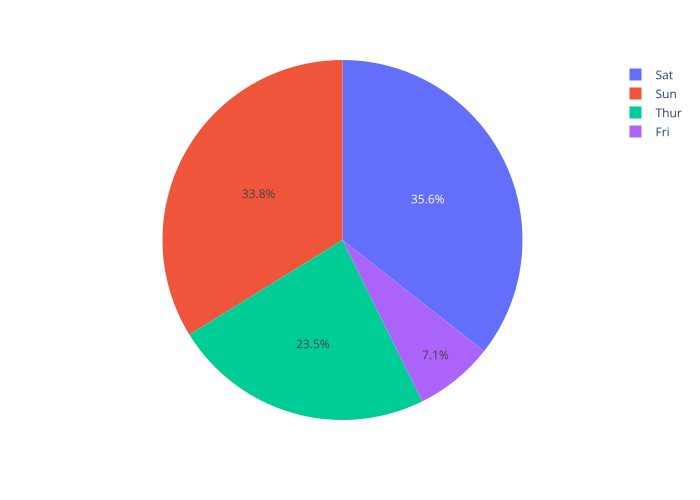

In [25]:
fig = px.pie(df_tip, names='day', values='tip', template='plotly')
fig.show(renderer='svg', height=500)

#### Donut chart

In [2]:
df_tip = px.data.tips()
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


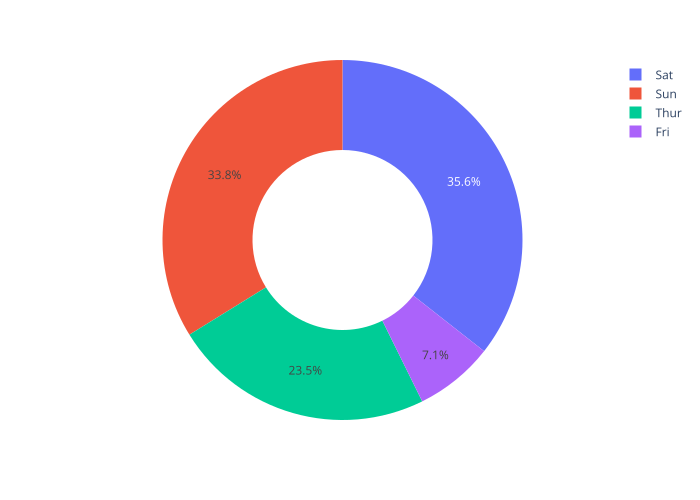

In [14]:
fig = px.pie(df_tip, names='day', values='tip', hole=.5)
fig.show(renderer='svg', height=500)

### 2.2. Bar chart
Plotly provides [bar charts] via the function <code style="font-size:13px">[px.bar()]</code>.

[px.bar()]: https://plotly.com/python-api-reference/generated/plotly.express.bar.html
[bar charts]: https://plotly.com/python/bar-charts/

In [1]:
import numpy as np
import pandas as pd
import janitor
import plotly.express as px
import plotly.graph_objects as go

#### Grouping and stacking

In [15]:
df_sales = pd.read_csv('../data/supermarket_sales.csv')
df_sales = df_sales[['invoice_id', 'payment', 'product_line', 'gender', 'profit', 'customer_type', 'city']]
df_sales.head()

,invoice_id,payment,product_line,gender,profit,customer_type,city
0,750-67-8428,Ewallet,Health and beauty,Female,26.1415,Member,Yangon
1,226-31-3081,Cash,Electronic accessories,Female,3.8200,Normal,Naypyitaw
2,631-41-3108,Credit card,Home and lifestyle,Male,16.2155,Normal,Yangon
3,123-19-1176,Ewallet,Health and beauty,Male,23.2880,Member,Yangon
4,373-73-7910,Ewallet,Sports and travel,Male,30.2085,Normal,Yangon


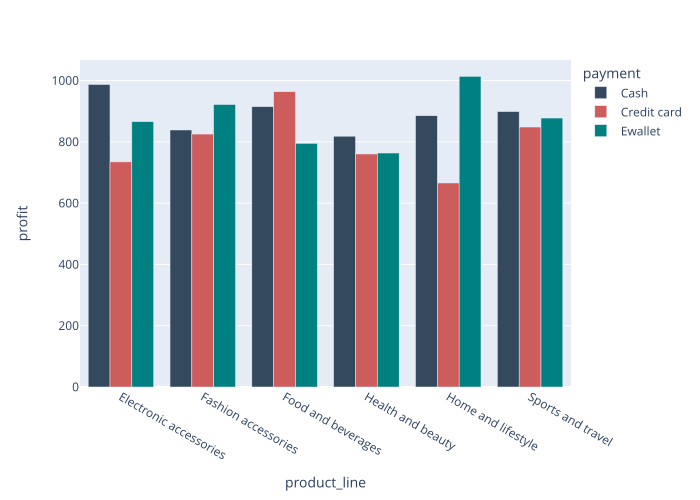

In [17]:
fig = px.bar(
    df_sales.groupby(['payment', 'product_line']).sum().reset_index(),
    x='product_line',
    y='profit',
    color='payment',
    barmode='group',
    color_discrete_sequence=['#34495e', 'indianred', 'teal']
)
fig.show(renderer='svg')

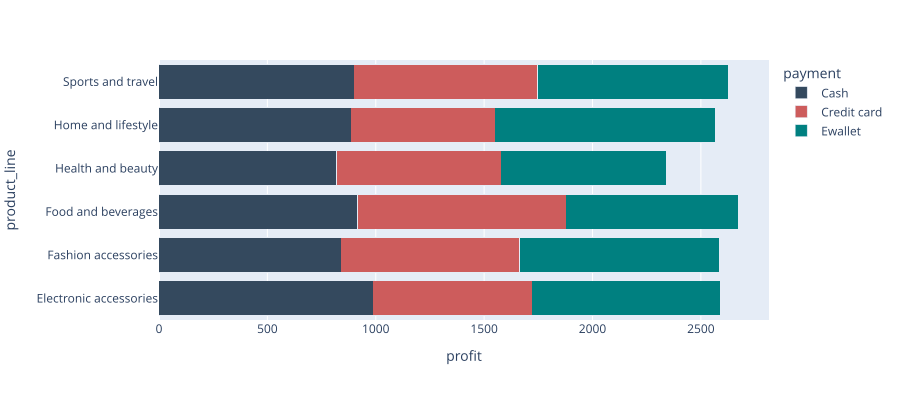

In [24]:
fig = px.bar(
    df_sales.groupby(['payment', 'product_line']).sum().reset_index(),
    y='product_line',
    x='profit',
    color='payment',
    barmode='stack',
    color_discrete_sequence=['#34495e', 'indianred', 'teal']
)
fig.show(renderer='svg', height=400, width=900)

#### Facet grid

In [3]:
df_sales = pd.read_csv('../data/supermarket_sales.csv')
df_sales = df_sales[['invoice_id', 'payment', 'product_line', 'gender', 'profit', 'customer_type', 'city']]
df_sales.head()

,invoice_id,payment,product_line,gender,profit,customer_type,city
0,750-67-8428,Ewallet,Health and beauty,Female,26.1415,Member,Yangon
1,226-31-3081,Cash,Electronic accessories,Female,3.8200,Normal,Naypyitaw
2,631-41-3108,Credit card,Home and lifestyle,Male,16.2155,Normal,Yangon
3,123-19-1176,Ewallet,Health and beauty,Male,23.2880,Member,Yangon
4,373-73-7910,Ewallet,Sports and travel,Male,30.2085,Normal,Yangon


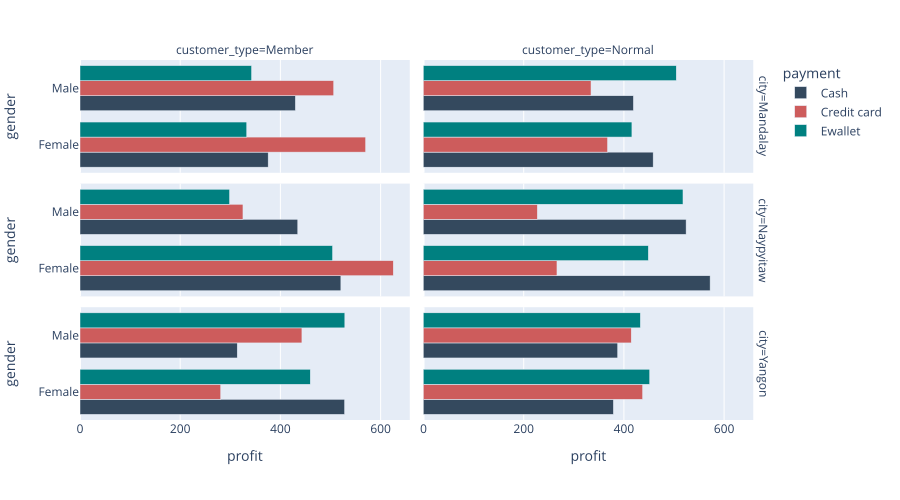

In [31]:
fig = px.bar(
    df_sales.groupby(['payment', 'gender', 'city', 'customer_type']).sum().reset_index(),
    y='gender',
    x='profit',
    color='payment',
    facet_row='city',
    facet_col='customer_type',
    color_discrete_sequence=['#34495e', 'indianred', 'teal'],
    barmode='group'
)
fig.show(renderer='svg', width=900)

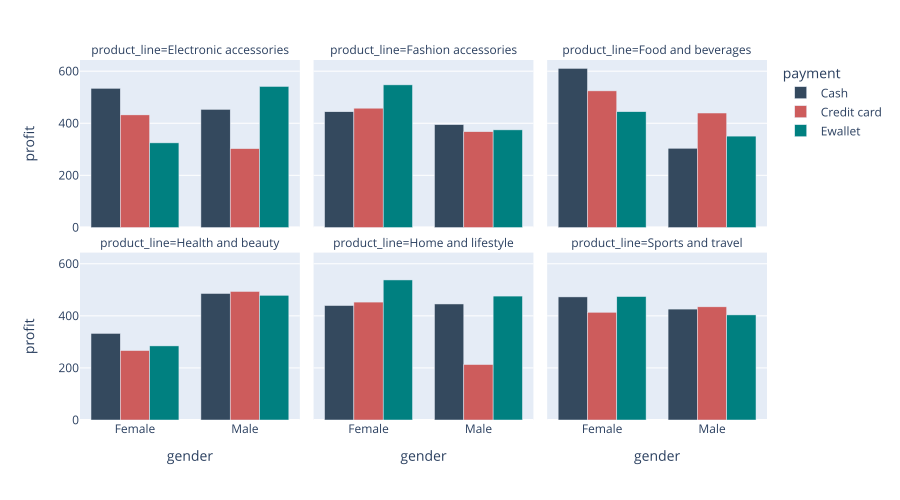

In [33]:
fig = px.bar(
    df_sales.groupby(['payment', 'gender', 'product_line']).sum().reset_index(),
    x='gender',
    y='profit',
    color='payment',
    facet_col='product_line',
    facet_col_wrap=3,
    color_discrete_sequence=['#34495e', 'indianred', 'teal'],
    barmode='group'
)
fig.show(renderer='svg', width=900)

#### Slider

In [4]:
countries = ['GNQ', 'BWA', 'GAB', 'PRI', 'NZL', 'AUS', 'CAN', 'CHE', 'HKG', 'IRL', 'USA', 'SGP', 'KWT', 'NOR']
df_world = pd.read_csv('../data/gapminder.csv')
df_world = df_world[df_world.iso_alpha.isin(countries)]
df_world = df_world.reset_index()
df_world.head()

,index,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,60,Australia,Oceania,1952,69.12,8691212,10039.59564,AUS,36
1,61,Australia,Oceania,1957,70.33,9712569,10949.64959,AUS,36
2,62,Australia,Oceania,1962,70.93,10794968,12217.22686,AUS,36
3,63,Australia,Oceania,1967,71.10,11872264,14526.12465,AUS,36
4,64,Australia,Oceania,1972,71.93,13177000,16788.62948,AUS,36


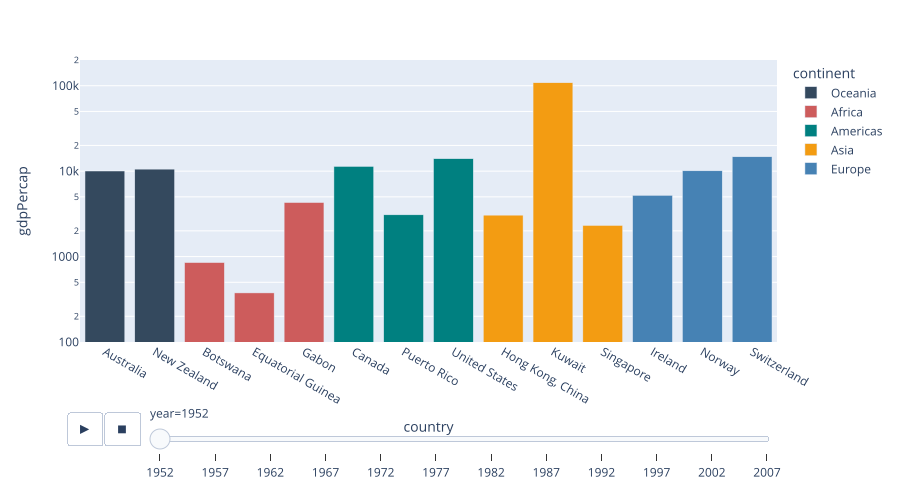

In [8]:
fig = px.bar(
    df_world,
    x='country', y='gdpPercap', color='continent',
    animation_frame='year',
    log_y=True,
    range_y=[100, 200000],
    color_discrete_sequence=['#34495e', 'indianred', 'teal', '#F39C12', 'steelblue']
)
fig.show(renderer='svg', width=900)

plotly.io.write_html(fig, file='../output/chap-05/animated_bar_chart.html')

#### Dot plot

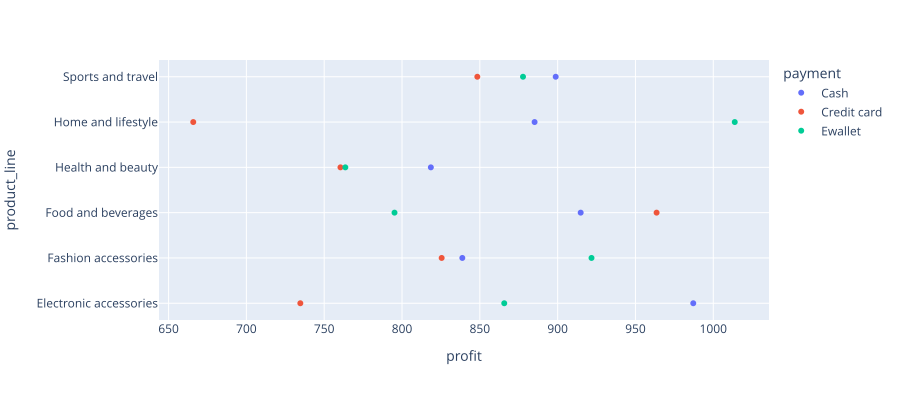

In [40]:
fig = px.scatter(
    df_sales.groupby(['payment', 'product_line']).sum().reset_index(),
    y='product_line',
    x='profit',
    color='payment',
#     color_discrete_sequence=['#34495e', 'indianred', 'teal']
)
fig.show(renderer='svg', height=400, width=900)

### 2.3. Line chart
Plotly provides [line charts] via the function <code style="font-size:13px">[px.line()]</code>.

[px.line()]: https://plotly.com/python-api-reference/generated/plotly.express.line
[line charts]: https://plotly.com/python/line-charts/

In [16]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [41]:
df_world = pd.read_csv('../data/gapminder.csv')
df_world = df_world.reset_index()
df_world.head()

,index,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


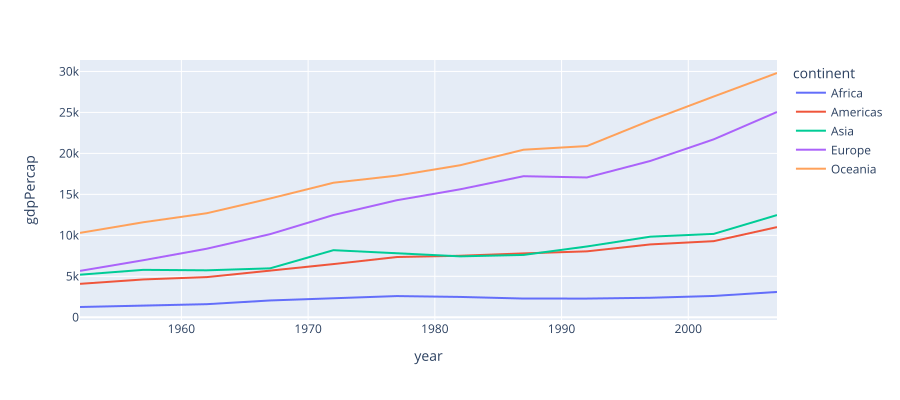

In [45]:
fig = px.line(
    df_world.groupby(['continent', 'year'])['gdpPercap'].mean().reset_index(),
    x='year',
    y='gdpPercap',
    color='continent'
)
fig.show(renderer='svg', height=400, width=900)

#### Slider

In [9]:
df_apple = pd.read_csv('../data/finance_charts_apple.csv')
df_apple.columns = [col.replace("AAPL.", '') for col in df_apple.columns]
df_apple.head().round(2)

,Date,Open,High,Low,Close,Volume,Adjusted,dn,mavg,up,direction
0,2015-02-17,127.49,128.88,126.92,127.83,63152400,122.91,106.74,117.93,129.11,Increasing
1,2015-02-18,127.63,128.78,127.45,128.72,44891700,123.76,107.84,118.94,130.04,Increasing
2,2015-02-19,128.48,129.03,128.33,128.45,37362400,123.50,108.89,119.89,130.88,Decreasing
3,2015-02-20,128.62,129.50,128.05,129.50,48948400,124.51,109.79,120.76,131.74,Increasing
4,2015-02-23,130.02,133.00,129.66,133.00,70974100,127.88,110.37,121.72,133.07,Increasing


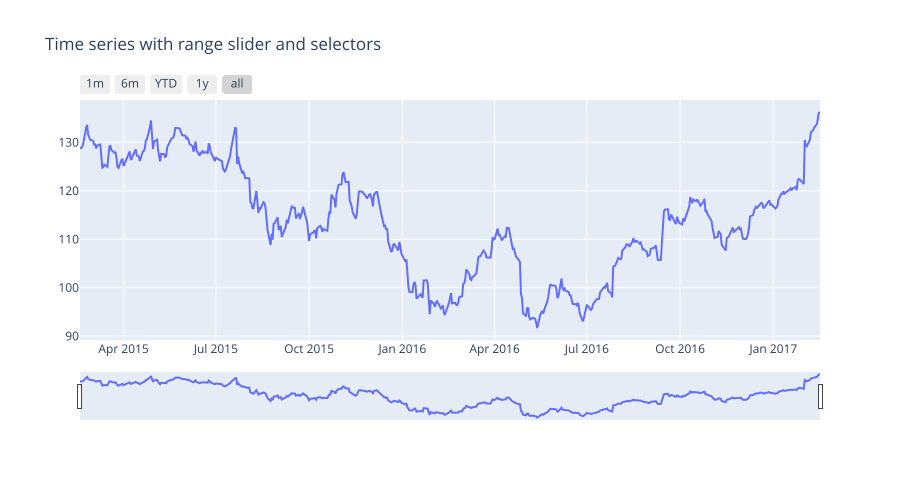

In [12]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=list(df_apple.Date), y=list(df_apple.High)))
fig.update_layout(title_text='Time series with range slider and selectors')

# range slider
fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label='1m', step='month', stepmode='backward'),
                dict(count=6, label='6m', step='month', stepmode='backward'),
                dict(count=1, label='YTD', step='year', stepmode='todate'),
                dict(count=1, label='1y', step='year', stepmode='backward'),
                dict(step='all')
            ])
        ),
        rangeslider=dict(visible=True),
        type='date'
    )
)

fig.show(renderer='svg', width=900)

### 2.4. Scatter plot
Plotly provides [scatter plots] via the function <code style="font-size:13px">[px.scatter()]</code>.

[px.scatter()]: https://plotly.com/python-api-reference/generated/plotly.express.scatter.html
[scatter plots]: https://plotly.com/python/line-and-scatter/

In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

#### Dot plot

In [13]:
df_sales = pd.read_csv('../data/supermarket_sales.csv')
df_sales = df_sales[['invoice_id', 'payment', 'product_line', 'gender', 'profit', 'customer_type', 'city']]
df_sales.head()

,invoice_id,payment,product_line,gender,profit,customer_type,city
0,750-67-8428,Ewallet,Health and beauty,Female,26.1415,Member,Yangon
1,226-31-3081,Cash,Electronic accessories,Female,3.8200,Normal,Naypyitaw
2,631-41-3108,Credit card,Home and lifestyle,Male,16.2155,Normal,Yangon
3,123-19-1176,Ewallet,Health and beauty,Male,23.2880,Member,Yangon
4,373-73-7910,Ewallet,Sports and travel,Male,30.2085,Normal,Yangon


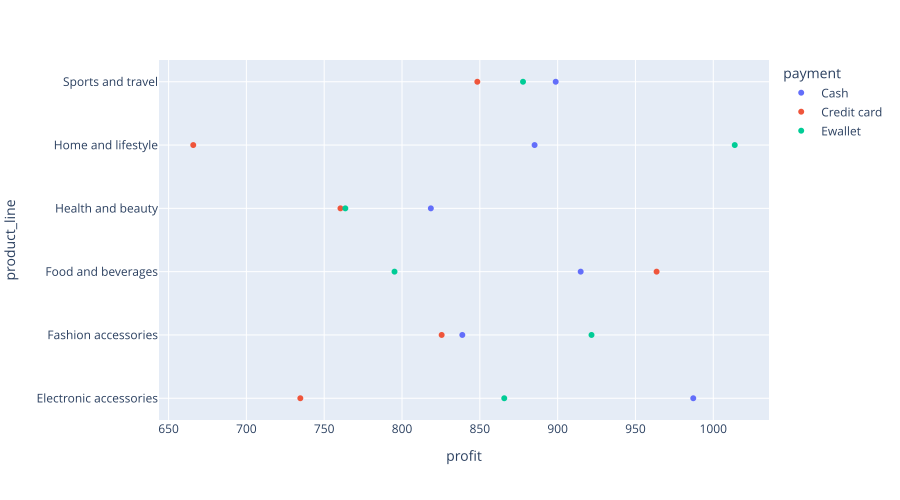

In [15]:
fig = px.scatter(
    df_sales.groupby(['payment', 'product_line']).sum().reset_index(),
    y='product_line',
    x='profit',
    color='payment',
)
fig.show(renderer='svg', width=900)

#### 3D scatter plot

In [16]:
df_iris = px.data.iris()
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


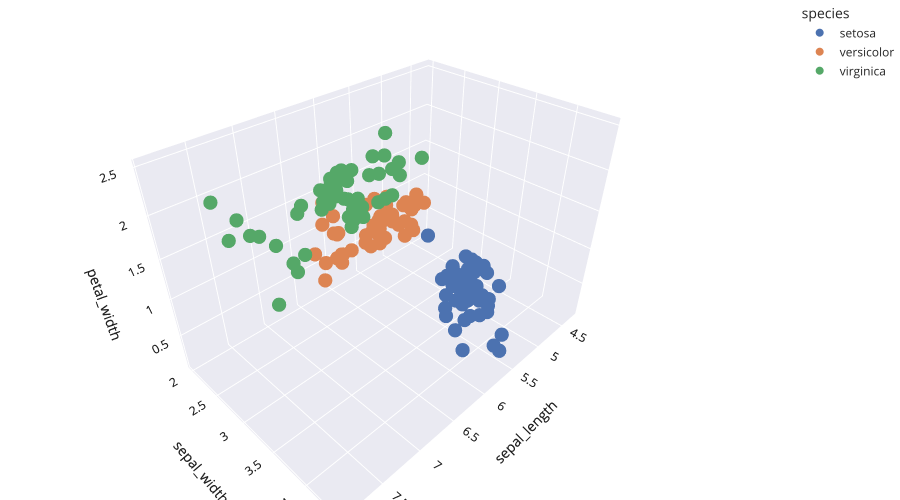

In [21]:
fig = px.scatter_3d(
    df_iris,
    x='sepal_length',
    y='sepal_width',
    z='petal_width',
    color='species',
    template='seaborn'
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show(renderer='svg', width=900)

#### Slider

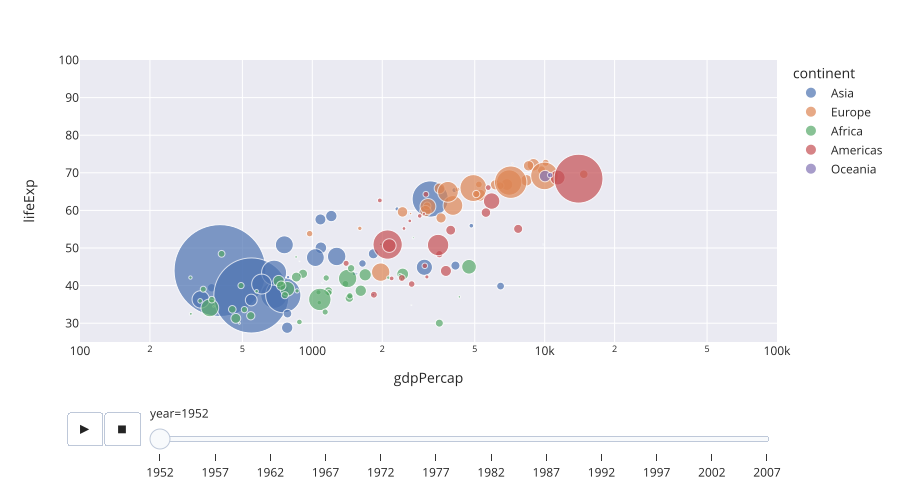

In [22]:
fig = px.scatter(
    px.data.gapminder(), 
    x='gdpPercap', y='lifeExp',
    size='pop', color='continent',
    animation_frame='year',
    hover_name='country',
    log_x=True,
    size_max=100,
    range_x=[100,100000],
    range_y=[25,100],
    template='seaborn'
)

fig.show(renderer='svg', width=900)

### 2.5. Radar chart
Plotly provides [radar charts] via the function [`px.line_polar()`].

[radar charts]: https://plotly.com/python/polar-chart/
[`px.line_polar()`]: https://plotly.com/python-api-reference/generated/plotly.express.line_polar.html

In [27]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

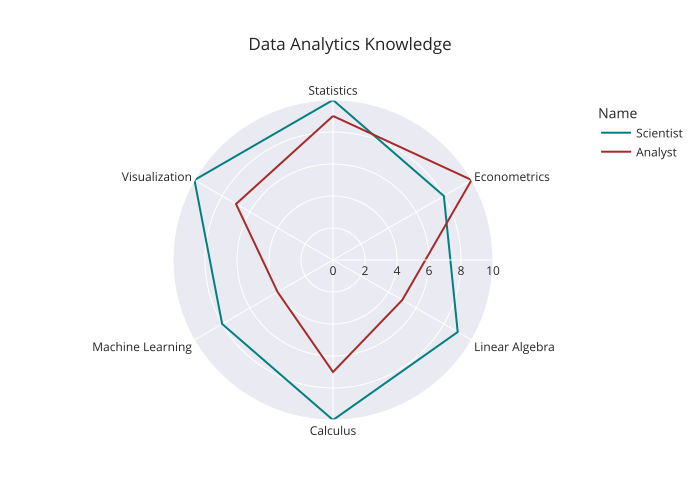

In [25]:
df_knowledge = pd.DataFrame({
    'Subject': ['Statistics', 'Econometrics', 'Linear Algebra', 'Calculus', 'Machine Learning', 'Visualization'],
    'Scientist': [10, 8, 9, 10, 8, 10],
    'Analyst': [9, 10, 5, 7, 4, 7],
}).melt(id_vars='Subject', var_name='Name', value_name='Score')

fig = px.line_polar(
    df_knowledge, r='Score', theta='Subject', color='Name',
    line_close=True,
    color_discrete_sequence=['teal', 'brown'],
    template='seaborn', title='Data Analytics Knowledge'
)
fig.show(renderer='svg')

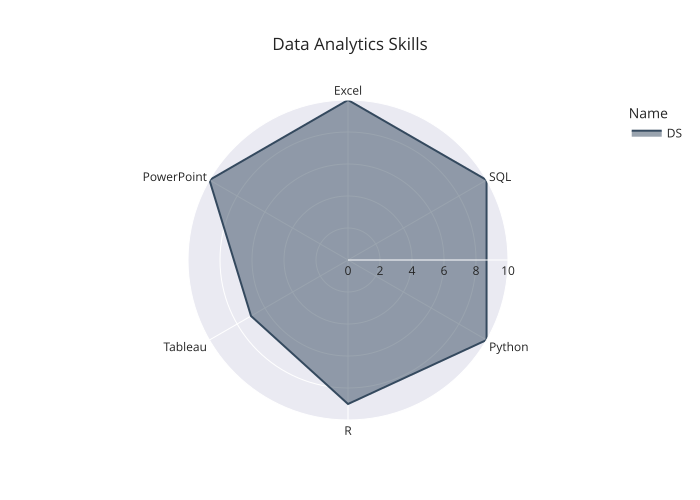

In [27]:
df_skills = pd.DataFrame({
    'Skills': ['Excel', 'SQL', 'Python', 'R', 'Tableau', 'PowerPoint'],
    'Score': [10, 10, 10, 9, 7, 10],
    'Name': ['DS']*6
})

fig = px.line_polar(
    df_skills, r='Score', theta='Skills', color='Name',
    line_close=True,
    color_discrete_sequence=['#34495E'],
    template='seaborn', title='Data Analytics Skills'
)
fig.update_traces(fill='toself')
fig.show(renderer='svg')

### 2.6. Gantt chart
Plotly provides [gantt charts] via the function <code style="font-size:13px">[px.timeline()]</code>.

[px.timeline()]: https://plotly.com/python-api-reference/generated/plotly.express.timeline.html
[gantt charts]: https://plotly.com/python/gantt/

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [30]:
data = [
    ['Phase A', 'Task A1', '2020-06-01', '2020-06-15'],
    ['Phase A', 'Task A2', '2020-06-15', '2020-06-22'],
    ['Phase A', 'Task A3', '2020-06-22', '2020-06-30'],
    ['Phase B', 'Task B1', '2020-07-01', '2020-07-20'],
    ['Phase B', 'Task B2', '2020-07-15', '2020-07-31'],
    ['Phase B', 'Task B3', '2020-08-01', '2020-08-20'],
    ['Phase B', 'Task B1', '2020-08-01', '2020-08-05'],
    ['Phase B', 'Task B4', '2020-08-12', '2020-08-21'],
    ['Phase B', 'Task B5', '2020-08-15', '2020-09-05'],
    ['Phase B', 'Task B2', '2020-08-20', '2020-08-31'],
    ['Phase C', 'Task C1', '2020-09-01', '2020-09-27'],
    ['Phase C', 'Task C2', '2020-09-25', '2020-10-05'],
    ['Phase C', 'Task C3', '2020-10-05', '2020-10-15'],
    ['Phase C', 'Task C4', '2020-10-15', '2020-10-30'],
]

columns = ['phase', 'task', 'start', 'end']

In [31]:
df_timeline = pd.DataFrame(data=data, columns=columns)
df_timeline.head(3)

,phase,task,start,end
0,Phase A,Task A1,2020-06-01,2020-06-15
1,Phase A,Task A2,2020-06-15,2020-06-22
2,Phase A,Task A3,2020-06-22,2020-06-30


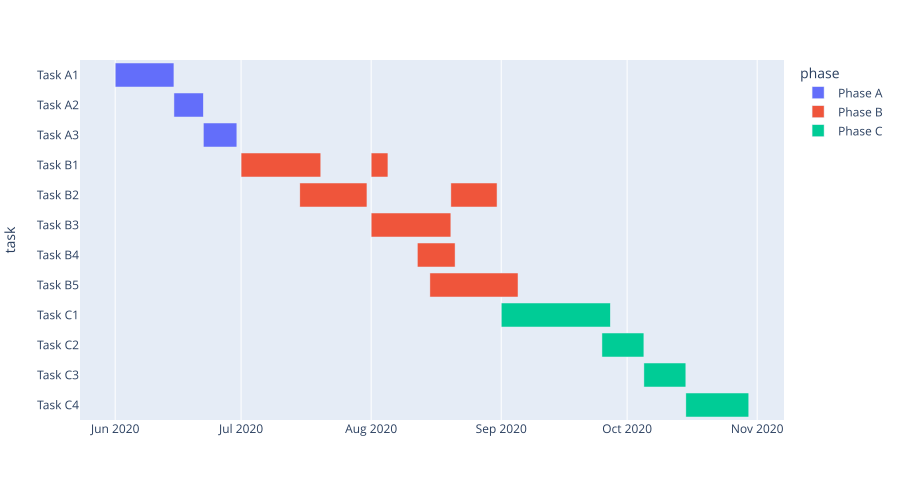

In [32]:
fig = px.timeline(
    df_timeline,
    x_start='start',
    x_end='end',
    y='task',
    color='phase'
)
fig.update_yaxes(autorange='reversed')
fig.show(renderer='svg', width=900)

### 2.7. Violin plot
Plotly provides the [violin plots] via the function <code style="font-size:13px">[px.violin()]</code>.

[px.violin()]: https://plotly.com/python-api-reference/generated/plotly.express.violin.html
[violin plots]: https://plotly.com/python/violin/

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [36]:
df_tip = sns.load_dataset('tips')
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


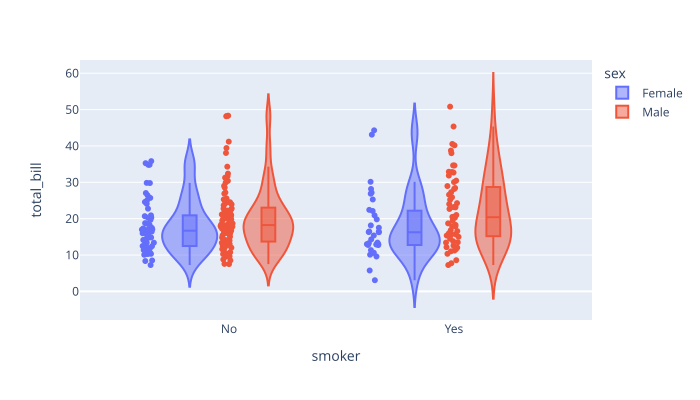

In [38]:
fig = px.violin(
    df_tip,
    x='smoker',
    y='total_bill',
    color='sex',
    box=True,
    points='all'
)
fig.show(renderer='svg', height=400)

## 3. Advanced charts

### 3.1. Sunburst chart
Plotly provides [sunbursts charts] via the function <code style="font-size:13px">[px.sunburst()]</code>.

[px.sunburst()]: https://plotly.com/python-api-reference/generated/plotly.express.sunburst.html
[sunbursts charts]: https://plotly.com/python/sunburst-charts/

In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [12]:
df_tip = px.data.tips()
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


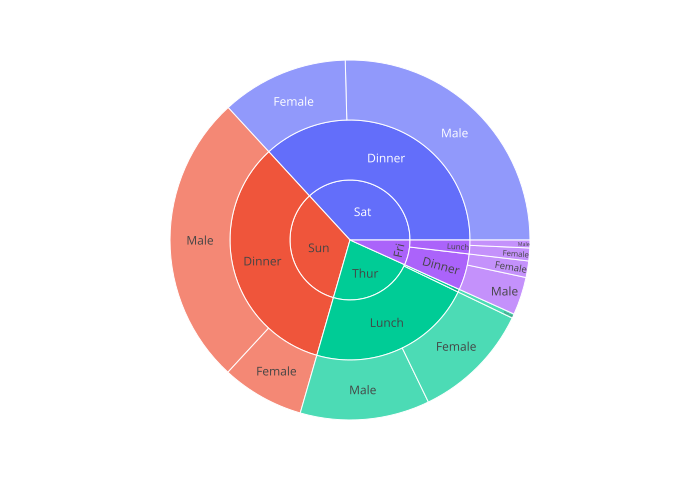

In [14]:
fig = px.sunburst(df_tip, path=['day', 'time', 'sex'], values='total_bill')
fig.show(renderer='svg')

### 3.2. Tree map
Plotly provides [tree maps] via the function <code style="font-size:13px">[px.treemap()]</code>.

[px.treemap()]: https://plotly.com/python-api-reference/generated/plotly.express.treemap.html
[tree maps]: https://plotly.com/python/treemaps/

In [15]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [16]:
df_world = pd.read_csv('../data/gapminder.csv')
df_world['world'] = 'World'
df_world = df_world[df_world.year==2007]
df_world.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num,world
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4,World
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8,World
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12,World
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24,World
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32,World


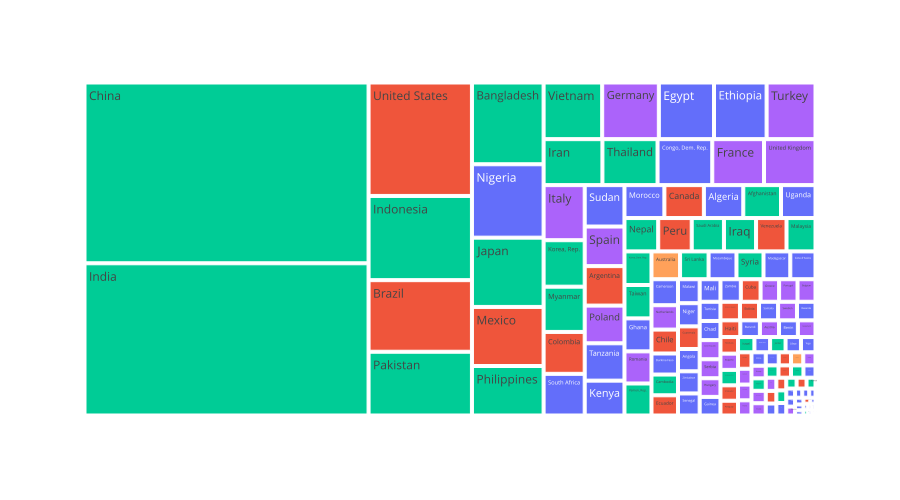

In [35]:
fig = px.treemap(
    df_world,
    values='pop',
    path=['country'],
    color='continent'
)
fig.show(renderer='svg', width=900)

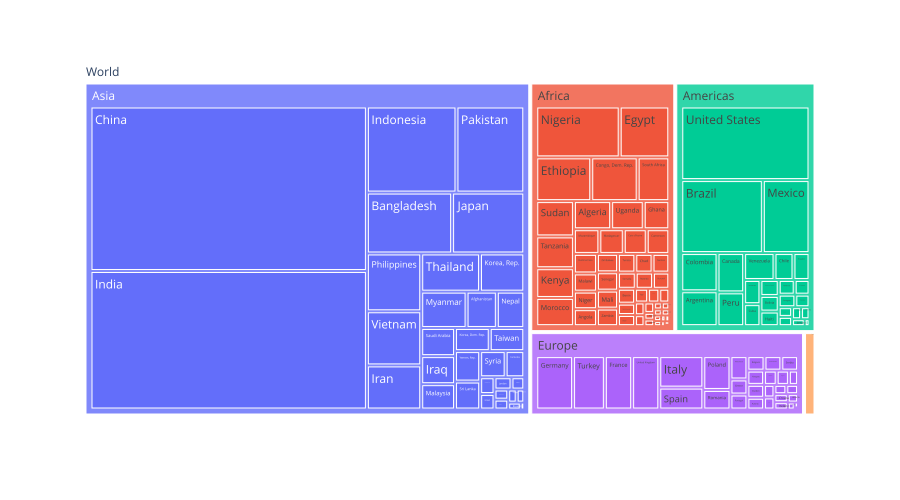

In [34]:
fig = px.treemap(
    df_world,
    values='pop',
    path=['world', 'continent', 'country'],
)
fig.show(renderer='svg', width=900)

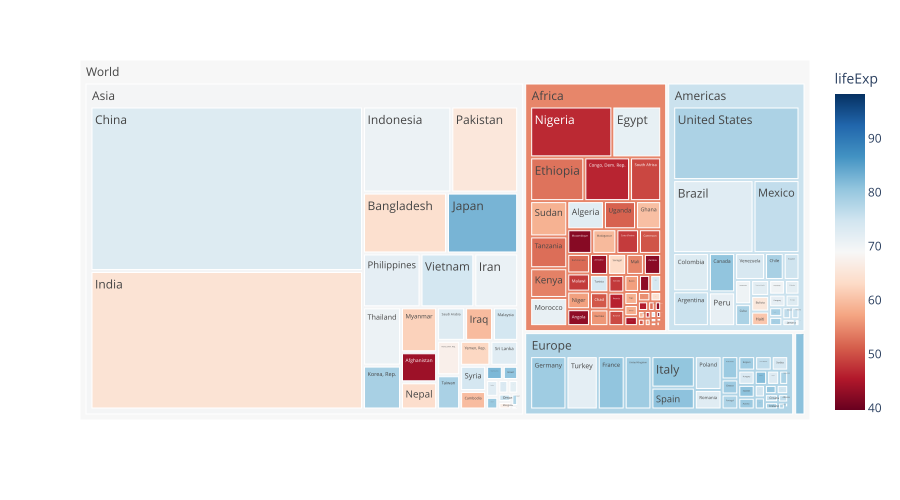

In [33]:
fig = px.treemap(
    df_world,
    values='pop',
    path=['world', 'continent', 'country'],
    color='lifeExp',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=np.average(df_world['lifeExp'], weights=df_world['pop'])
)
fig.show(renderer='svg', width=900)

### 3.3. Parallel set
Plotly provides [parallel sets] via the function <code style="font-size:13px">[px.parallel_categories()]</code>.

[parallel sets]: https://plotly.com/python/parallel-categories-diagram/
[px.parallel_categories()]: https://plotly.com/python-api-reference/generated/plotly.express.parallel_categories.html

In [44]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [45]:
df_tip = px.data.tips()
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


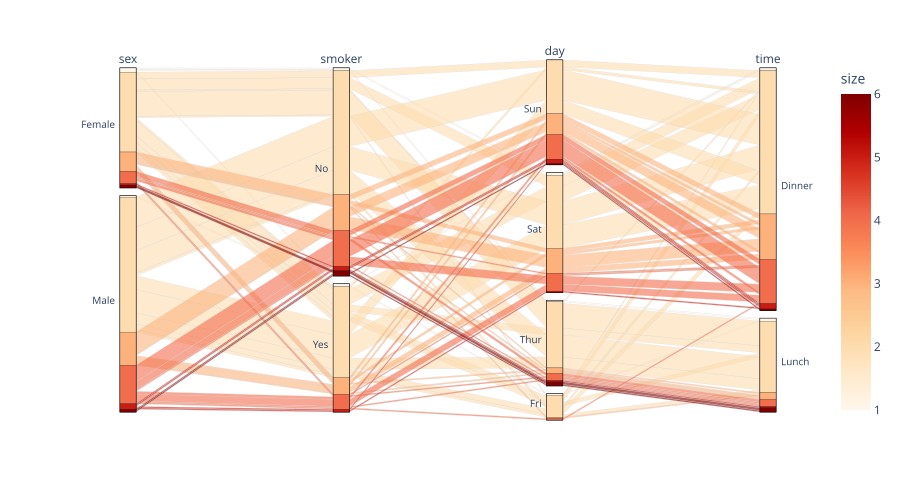

In [32]:
fig = px.parallel_categories(
    df_tip,
    dimensions=['sex', 'smoker', 'day', 'time'],
    color='size',
    color_continuous_scale='OrRd'
)
fig.show(renderer='svg', width=900)

### 3.4. Parallel coordinates
Plotly provides [parallel coordinates] via the function <code style="font-size:13px">[px.parallel_coordinates()]</code>.

[parallel coordinates]: https://plotly.com/python/parallel-coordinates-plot/
[px.parallel_coordinates()]: https://plotly.com/python-api-reference/generated/plotly.express.parallel_coordinates.html

In [47]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [22]:
df_iris = px.data.iris()
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


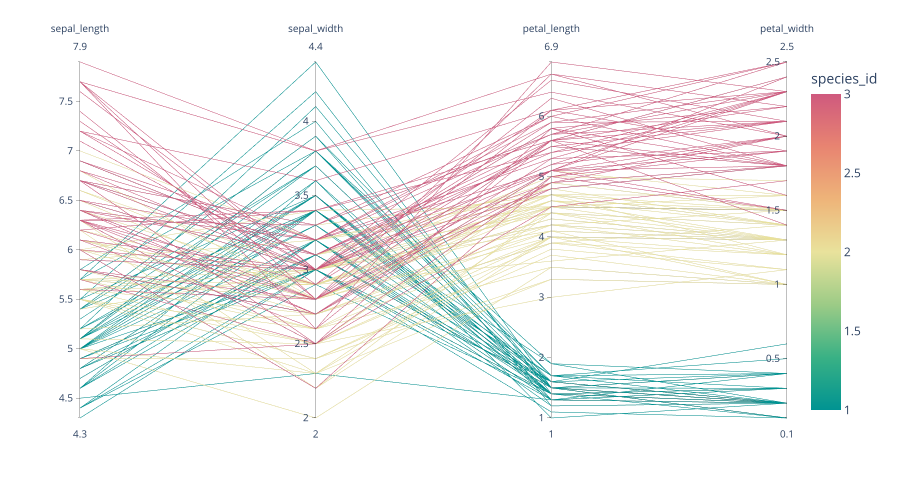

In [36]:
fig = px.parallel_coordinates(
    df_iris,
    color='species_id',
    dimensions=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    color_continuous_scale='Temps'
)
fig.show(renderer='svg', width=900)

## 4. Maps
Useful map styles that can be controlled using the <code style="font-size:13px">[mapbox_style]</code> parameter:
- <code style="font-size:13px">white-bg</code>
- <code style="font-size:13px">open-street-map</code>
- <code style="font-size:13px">carto-positron</code>
- <code style="font-size:13px">carto-darkmatter</code>
- <code style="font-size:13px">stamen-terrain</code>
- <code style="font-size:13px">stamen-toner</code>
- <code style="font-size:13px">stamen-watercolor</code>

Plotly also supports other style as well:
<code style="font-size:13px">basic</code>
<code style="font-size:13px">streets</code>
<code style="font-size:13px">outdoors</code>
<code style="font-size:13px">light</code>
<code style="font-size:13px">dark</code>
<code style="font-size:13px">satellite</code>
<code style="font-size:13px">satellite-streets</code>
but they require a Mapbox access token.

[`mapbox_style`]: https://plotly.com/python/mapbox-layers/

### 4.1. Density heat map
Plotly's [density heat maps] show the magnitude of phenomenons and where they locate. The <code style="font-size:13px">[px.density_mapbox()]</code> function has the notable parameters as follows:
- <code style="font-size:13px">lat</code>: the latitude
- <code style="font-size:13px">lon</code>: the longitude
- <code style="font-size:13px">z</code>: the magnitude or the size

[density heat maps]: https://plotly.com/python/mapbox-density-heatmaps/
[px.density_mapbox()]: https://plotly.com/python-api-reference/generated/plotly.express.density_mapbox

In [50]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [24]:
df_earthquake = pd.read_csv('../data/earthquakes.csv')
df_earthquake.head()

,Date,Latitude,Longitude,Magnitude
0,01/02/1965,19.246,145.616,6.0
1,01/04/1965,1.863,127.352,5.8
2,01/05/1965,-20.579,-173.972,6.2
3,01/08/1965,-59.076,-23.557,5.8
4,01/09/1965,11.938,126.427,5.8


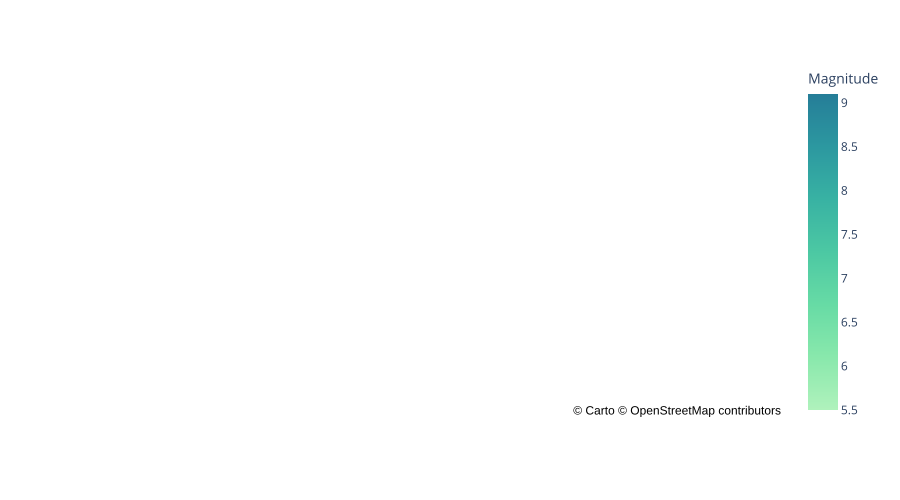

In [37]:
fig = px.density_mapbox(
    df_earthquake,
    lat='Latitude',
    lon='Longitude',
    z='Magnitude',
    radius=10,
    center={'lat':0, 'lon':180},
    zoom=1,
    color_continuous_scale='Tealgrn',
    mapbox_style="carto-positron")

fig.show(renderer='svg', width=900)

### 4.2. Bubble Map
[Bubble maps], implemented via <code style="font-size:13px">[px.scatter_mapbox()]</code> takes the same input as Density Heat Map.

[Bubble maps]: https://plotly.com/python/bubble-maps/
[px.scatter_mapbox()]: https://plotly.github.io/plotly.py-docs/generated/plotly.express.scatter_mapbox.html

In [53]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [27]:
df_carshare = px.data.carshare()
df_carshare.head()

,centroid_lat,centroid_lon,car_hours,peak_hour
0,45.471549,-73.588684,1772.750000,2
1,45.543865,-73.562456,986.333333,23
2,45.487640,-73.642767,354.750000,20
3,45.522870,-73.595677,560.166667,23
4,45.453971,-73.738946,2836.666667,19


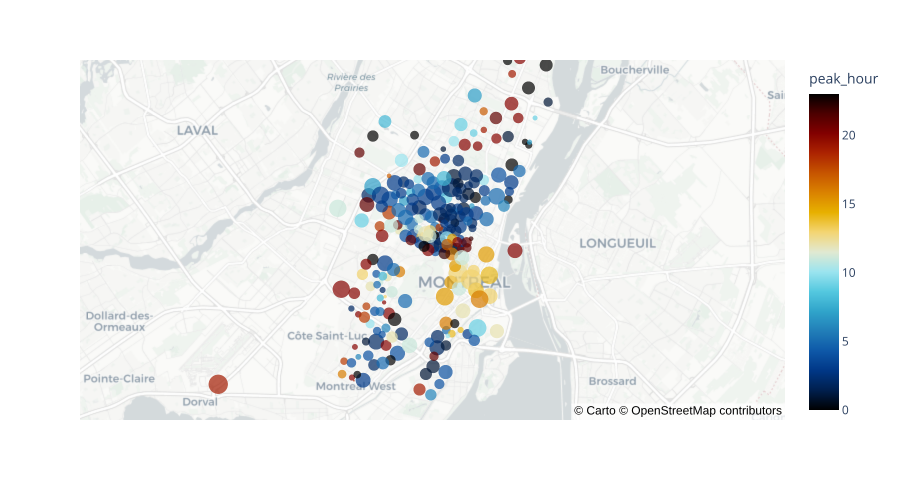

In [38]:
fig = px.scatter_mapbox(
    df_carshare,
    lat='centroid_lat', lon='centroid_lon',
    color='peak_hour', size='car_hours',
    color_continuous_scale=px.colors.cyclical.IceFire,
    size_max=15, zoom=10,
    mapbox_style='carto-positron')

fig.show(renderer='svg', width=900)

### 4.3. Choropleth map
[Choropleth maps] visualize a quantitative variable using colored polygons. The <code style="font-size:13px">[px.choropleth_mapbox()]</code> function has the notable parameters as follows:
- <code style="font-size:13px">geojson</code>: dictionary-styled geometry information that must contain the latitudes and the longitudes of polygon vertexes.
- <code style="font-size:13px">locations</code>: names of colored regions from data
- <code style="font-size:13px">featureidkey</code>: to specify the path used in <code style="font-size:13px">geojson</code> that match the value of <code style="font-size:13px">locations</code>.

[Choropleth maps]: https://plotly.com/python/choropleth-maps/
[px.choropleth_mapbox()]: https://plotly.github.io/plotly.py-docs/generated/plotly.express.choropleth_mapbox.html

In [56]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [29]:
df_election = px.data.election()
geojson = px.data.election_geojson()
df_election.head()

,district,Coderre,Bergeron,Joly,total,winner,result,district_id
0,101-Bois-de-Liesse,2481,1829,3024,7334,Joly,plurality,101
1,102-Cap-Saint-Jacques,2525,1163,2675,6363,Joly,plurality,102
2,11-Sault-au-Récollet,3348,2770,2532,8650,Coderre,plurality,11
3,111-Mile-End,1734,4782,2514,9030,Bergeron,majority,111
4,112-DeLorimier,1770,5933,3044,10747,Bergeron,majority,112


In [58]:
geojson['features'][0]['properties']

{'district': '11-Sault-au-Récollet'}

In [59]:
df_election.district[2]

'11-Sault-au-Récollet'

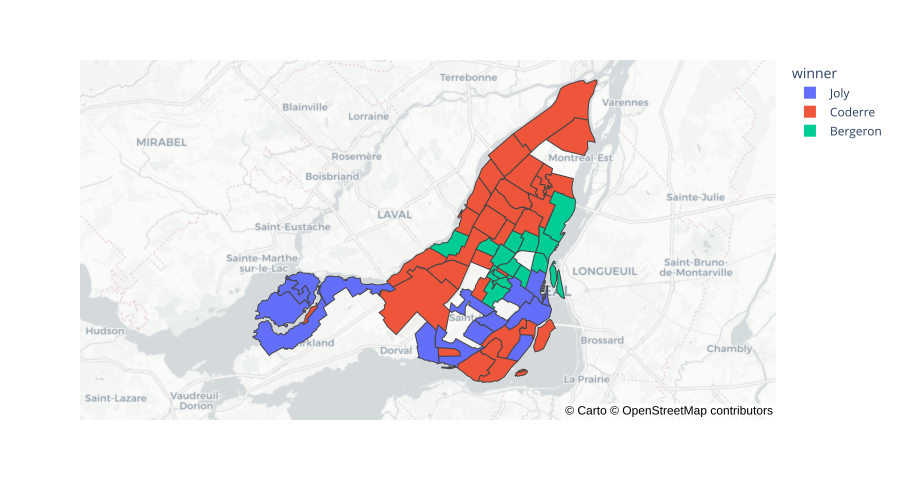

In [39]:
fig = px.choropleth_mapbox(
    df_election,
    geojson=geojson,
    color="winner",
    locations="district",
    featureidkey="properties.district",
    center={"lat": 45.5517, "lon": -73.707},
    zoom=9,
    mapbox_style='carto-positron')

fig.show(renderer='svg', width=900)

## Install

In [ ]:
jupyter labextension install jupyterlab-plotly@4.12.0

---
*&#9829; By Quang Hung x Thuy Linh &#9829;*